In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## Представление данных
Сегодня мы будем работать с доклад о мировом счастье за 2026 год, полученными из [Kaggle](https://www.kaggle.com/datasets/hassanali789/world-happiness-report-2026-official-rankings). Описание колонок представлено ниже:

- `rank` - Рейтинг счастья — 1 = самая счастливая страна
- `country` - Название страны
- `region` - Регион мира (например, Западная Европа, страны Африки к югу от Сахары)
- `score` - Оценка счастья по шкале Кэнтрила (0 = наихудшая из возможных жизней, 10 = наилучшая из возможных жизней)
- `gdp_per_capita` - Экономический результат на душу населения — логарифмическая шкала, отражающая вклад дохода в счастье
- `social_support` - Ощущаемая доступность кого-то, на кого можно положиться в трудную минуту
- `healthy_life_expectancy` - Ожидаемое количество лет, прожитых в добром здравии
- `freedom` - Удовлетворение свободой делать ключевой жизненный выбор
- `generosity` - Отношение благотворительности к ВВП
- `corruption` - Восприятие низкого уровня коррупции в правительстве и бизнесе — более высокая ценность означает меньшее восприятие коррупции

In [2]:
df = pd.read_csv('world_happiness_2026.csv')
df.head()

,rank,country,region,score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,corruption
0,1,Finland,Western Europe,7.764,1.892,1.581,0.952,0.670,0.186,0.498
1,2,Iceland,Western Europe,7.701,1.874,1.611,0.959,0.662,0.269,0.512
2,3,Denmark,Western Europe,7.688,1.887,1.562,0.948,0.665,0.211,0.495
3,4,Costa Rica,Latin America and Caribbean,7.439,1.254,1.421,0.891,0.631,0.178,0.312
4,5,Sweden,Western Europe,7.401,1.878,1.501,0.952,0.658,0.224,0.481


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   rank                     130 non-null    int64  
 1   country                  130 non-null    object 
 2   region                   130 non-null    object 
 3   score                    130 non-null    float64
 4   gdp_per_capita           130 non-null    float64
 5   social_support           130 non-null    float64
 6   healthy_life_expectancy  130 non-null    float64
 7   freedom                  130 non-null    float64
 8   generosity               130 non-null    float64
 9   corruption               130 non-null    float64
dtypes: float64(7), int64(1), object(2)
memory usage: 10.3+ KB


In [17]:
# Проверка на дубликаты
duplicates = df.duplicated().sum()
print(f"Количество дублирующихся строк: {duplicates}")

Количество дублирующихся строк: 0


In [21]:
# Проверка консистентности данных (убедиться, что 'rank' уникален и соответствует индексу)
if not df['rank'].is_unique:
    print("столбец 'rank' содержит дубликаты")

In [22]:
# Проверка, что 'score' не выходит за ожидаемые пределы (должен быть от 0 до 10)
if (df['score'] < 0).any() or (df['score'] > 10).any():
    print("столбец 'score' содержит значения вне ожидаемого диапазона")

## Изучение переменных
Для числовых переменных, построим соответствующие метрики и визуализации:

In [25]:
numerics = df.columns[3:]
df[numerics].describe().round(3)

,score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,corruption
count,130.000,130.000,130.000,130.000,130.000,130.000,130.000
mean,5.454,1.135,1.177,0.732,0.483,0.165,0.178
std,1.256,0.560,0.259,0.191,0.118,0.056,0.134
min,1.446,0.171,0.341,0.311,0.071,0.061,0.011
25%,4.136,0.671,0.941,0.564,0.394,0.131,0.071
50%,5.581,1.121,1.241,0.791,0.491,0.161,0.141
75%,6.396,1.631,1.378,0.891,0.571,0.201,0.261
max,7.764,2.121,1.611,0.961,0.671,0.301,0.512


Boxplots для числовых переменных:


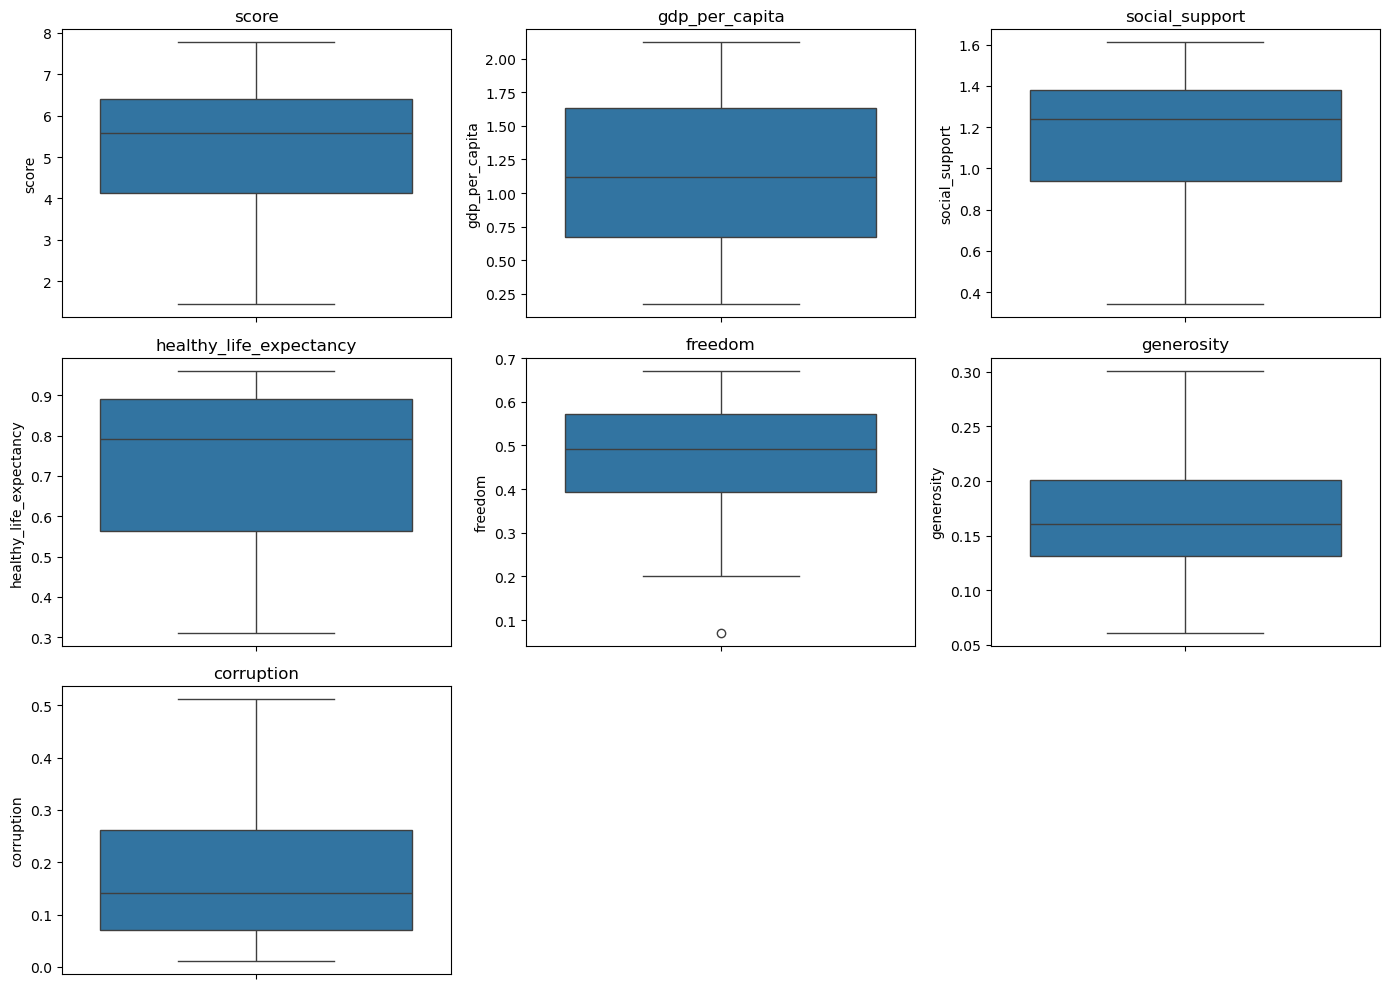

In [27]:
print("Boxplots для числовых переменных:")
plt.figure(figsize=(14, 10))
for i, col in enumerate(numerics):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

,score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,generosity,corruption
count,130.000,130.000,130.000,130.000,130.000,130.000,130.000
mean,5.454,1.135,1.177,0.732,0.483,0.165,0.178
std,1.256,0.560,0.259,0.191,0.118,0.056,0.134
min,1.446,0.171,0.341,0.311,0.071,0.061,0.011
25%,4.136,0.671,0.941,0.564,0.394,0.131,0.071
50%,5.581,1.121,1.241,0.791,0.491,0.161,0.141
75%,6.396,1.631,1.378,0.891,0.571,0.201,0.261
max,7.764,2.121,1.611,0.961,0.671,0.301,0.512


Изучение взаимосвязи таргета ('score') с другими переменными

In [31]:
target = 'score'
# Исключим 'rank', 'country' и 'region' из коррялионного анализа, они не являются прямыми факторами счастья
features_for_correlation = ['gdp_per_capita', 'social_support', 'healthy_life_expectancy', 'freedom', 'generosity', 'corruption']

# Расчет коэффициентов корреляции
print(f"Коэффициенты корреляции с таргетом '{target}':")
correlation_matrix = df[features_for_correlation + [target]].corr()
print(correlation_matrix[target].drop(target)) # Выводим корреляцию с таргетом



Коэффициенты корреляции с таргетом 'score':
gdp_per_capita             0.879284
social_support             0.976465
healthy_life_expectancy    0.900567
freedom                    0.932961
generosity                 0.236826
corruption                 0.874750
Name: score, dtype: float64


Scatterplots для взаимосвязи таргета ('score') с числовыми переменными:


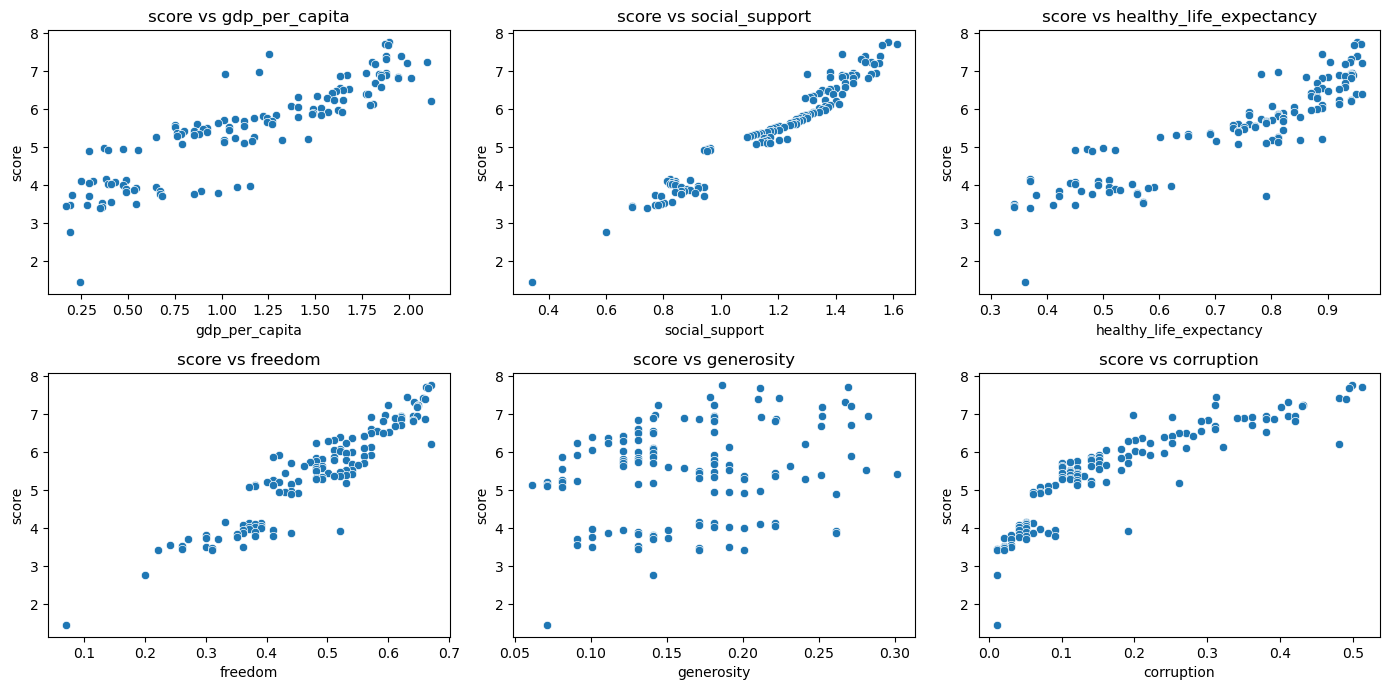

In [32]:
# Построение scatterplots для числовых переменных
print("Scatterplots для взаимосвязи таргета ('score') с числовыми переменными:")
plt.figure(figsize=(14, 10))
for i, col in enumerate(features_for_correlation):
    plt.subplot(3, 3, i + 1)
    sns.scatterplot(x=df[col], y=df[target])
    plt.title(f'{target} vs {col}')
plt.tight_layout()
plt.show()

##### из анализа, можно сделать вывод, что на счастье, больше всего, влияет `социальная поддержка`, а так же свобода и здоровье.

## Парная линейная регрессия

In [38]:
from sklearn.linear_model import LinearRegression

In [57]:
# Выбираем X ('social_support') и Y ('score')
X_prev = df[['social_support']]
Y = df['score']
model_prev = LinearRegression()
model_prev.fit(X_prev, Y)
K_prev = model_prev.coef_[0]
B_prev = model_prev.intercept_
R2_prev = model_prev.score(X_prev, Y)

In [68]:
print(f"Линейное уравнение: score = {K_prev:.3f} * social_support + {B_prev:.3f}")

Линейное уравнение: score = 4.732 * social_support + -0.114


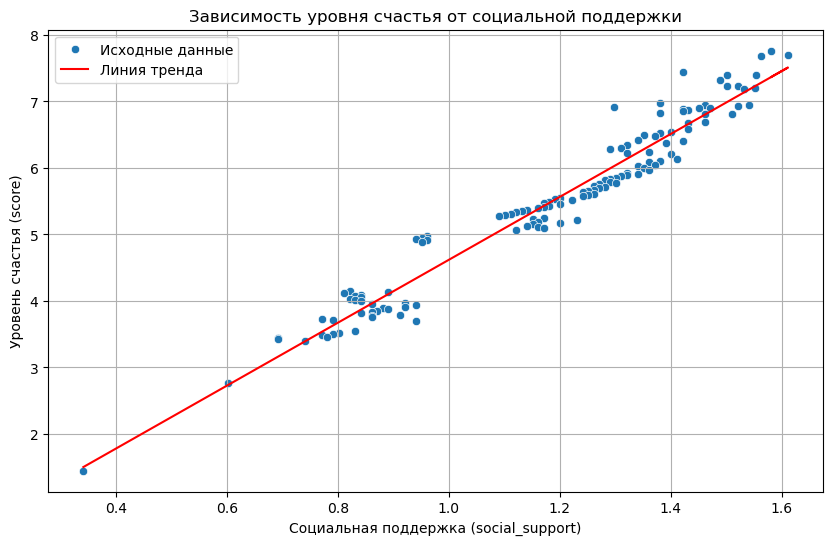

In [59]:
# Построение графика
plt.figure(figsize=(10, 6))
sns.scatterplot(x='social_support', y='score', data=df, label='Исходные данные') # Исходные данные
plt.plot(X, model.predict(X), color='red', label='Линия тренда') # Линия тренда
plt.title('Зависимость уровня счастья от социальной поддержки')
plt.xlabel('Социальная поддержка (social_support)')
plt.ylabel('Уровень счастья (score)')
plt.legend()
plt.grid(True)
plt.show()

In [60]:
print(f"  При увеличении 'social_support' на 1 единицу, 'score' (уровень счастья) ожидаемо увеличивается на {K:.3f}. \nЭто является значимым изменением, так как коэффициент ({K:.3f}) положителен и заметно отличается от нуля.")

  При увеличении 'social_support' на 1 единицу, 'score' (уровень счастья) ожидаемо увеличивается на 4.732. 
Это является значимым изменением, так как коэффициент (4.732) положителен и заметно отличается от нуля.


#### добавляем 'gdp_per_capita' как вторую независимую переменную

In [67]:
X_new = df[['social_support', 'gdp_per_capita']]
model_new = LinearRegression()
model_new.fit(X_new, Y)

# Получение коэффициентов новой модели
K_social_support_new = model_new.coef_[0]
K_gdp_new = model_new.coef_[1]
B_new = model_new.intercept_
R2_new = model_new.score(X_new, Y)

print(f"Коэффициент 'social_support' изменился с {K_prev:.3f} на {K_social_support_new:.3f}.")
# В данном контексте "значимость" можно оценить по изменению величины коэффициента,
# но без статистических тестов (p-value) это приближенная оценка.
if abs(K_social_support_new) > abs(K_prev):
    print("Величина коэффициента 'social_support' увеличилась, что может указывать на его возросшую роль или изменение взаимосвязи.")
else:
    print("Величина коэффициента 'social_support' уменьшилась, что может указывать на то, что влияние этой переменной частично объясняется новой переменной.")

Коэффициент 'social_support' изменился с 4.732 на 5.459.
Величина коэффициента 'social_support' увеличилась, что может указывать на его возросшую роль или изменение взаимосвязи.


#### Проверка изменения R²

In [66]:
print(f"R² изменился с {R2_prev:.3f} на {R2_new:.3f}.")
if R2_new > R2_prev:
    print("Увеличение R² указывает на то, что новая переменная ('gdp_per_capita') улучшает объясняющую способность модели.")
else:
    print("R² не изменился или уменьшился, что может означать, что новая переменная незначительно влияет на 'score' или вносит избыточность.")

# Обновленное уравнение
print("\n· Обновленное уравнение:")
print(f"  score = {K_social_support_new:.3f} * social_support + {K_gdp_new:.3f} * gdp_per_capita + {B_new:.3f}")


R² изменился с 0.953 на 0.957.
Увеличение R² указывает на то, что новая переменная ('gdp_per_capita') улучшает объясняющую способность модели.

· Обновленное уравнение:
  score = 5.459 * social_support + -0.364 * gdp_per_capita + -0.556


In [80]:
print(f"При увеличении 'gdp_per_capita' на 1 единицу, при фиксированном значении 'social_support', 'score' (уровень счастья) ожидаемо увеличивается на {K_gdp_new:.3f}.\nЭто говорит о положительном влиянии ВВП на душу населения на уровень счастья, даже при учете социальной поддержки.")


При увеличении 'gdp_per_capita' на 1 единицу, при фиксированном значении 'social_support', 'score' (уровень счастья) ожидаемо увеличивается на -0.364.
Это говорит о положительном влиянии ВВП на душу населения на уровень счастья, даже при учете социальной поддержки.


### Проверка на мультиколлинеарность

In [81]:
# Независимые переменные, которые будем проверять на мультиколлинеарность
independent_vars = df[['social_support', 'gdp_per_capita']]

In [83]:
correlation_matrix = independent_vars.corr()
print(f"· Коэффициент корреляции между 'social_support' и 'gdp_per_capita': {correlation_matrix.iloc[0, 1]:.3f}")



· Коэффициент корреляции между 'social_support' и 'gdp_per_capita': 0.925


### Расчет VIF (Variance Inflation Factor)

In [88]:
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [89]:
# Добавляем константу для расчета VIF
X_with_const = add_constant(independent_vars)

# Рассчитываем VIF для каждой независимой переменной
vif_data = pd.DataFrame()
vif_data["feature"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i)
                   for i in range(X_with_const.shape[1])]

# Выводим VIF, исключая константу
print("\n· VIF (Variance Inflation Factor) для независимых переменных:")
print(vif_data.iloc[1:]) # Пропускаем строку с 'const'


· VIF (Variance Inflation Factor) для независимых переменных:
          feature       VIF
1  social_support  6.890363
2  gdp_per_capita  6.890363


#### Высокие значения VIF (обычно > 5 или > 10) указывают на то,
что данная независимая переменная сильно коррелирует с другими независимыми переменными в модели, что может привести к нестабильности
оценок коэффициентов и затруднить интерпретацию их вклада.

## Проверка модели с двумя независимыми переменными на гетероскедастичность

In [91]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

In [92]:
# Определим зависимую и независимые переменные
y = df['score']
X = df[['social_support', 'gdp_per_capita']]
X = sm.add_constant(X) # Добавляем константу для регрессии

# Построение модели OLS
model = sm.OLS(y, X).fit()

#### График остатков

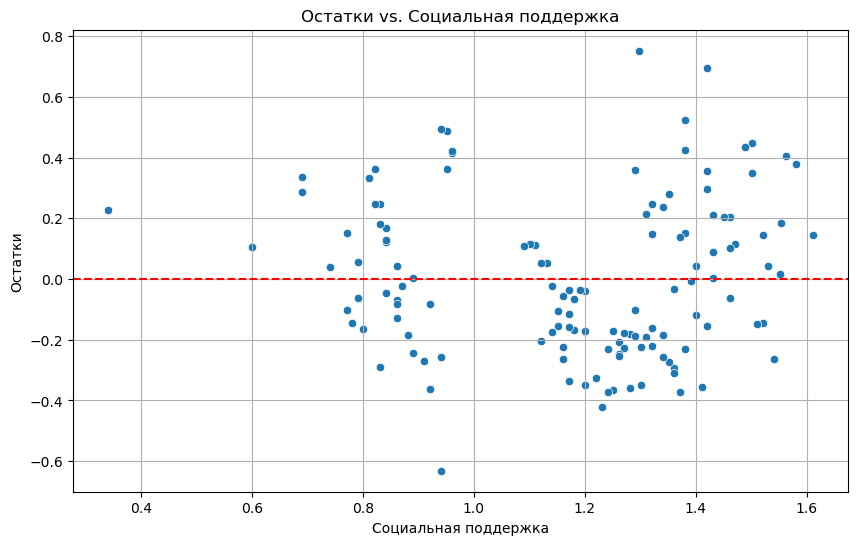

In [93]:
# Для построения графика остатков относительно каждой независимой переменной
# сначала предскажем значения Y, а затем найдем остатки.
df['fitted'] = model.predict(X)
df['residuals'] = df['score'] - df['fitted']

# График остатков относительно 'social_support'
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['social_support'], y=df['residuals'])
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Остатки vs. Социальная поддержка')
plt.xlabel('Социальная поддержка')
plt.ylabel('Остатки')
plt.grid(True)
plt.show()



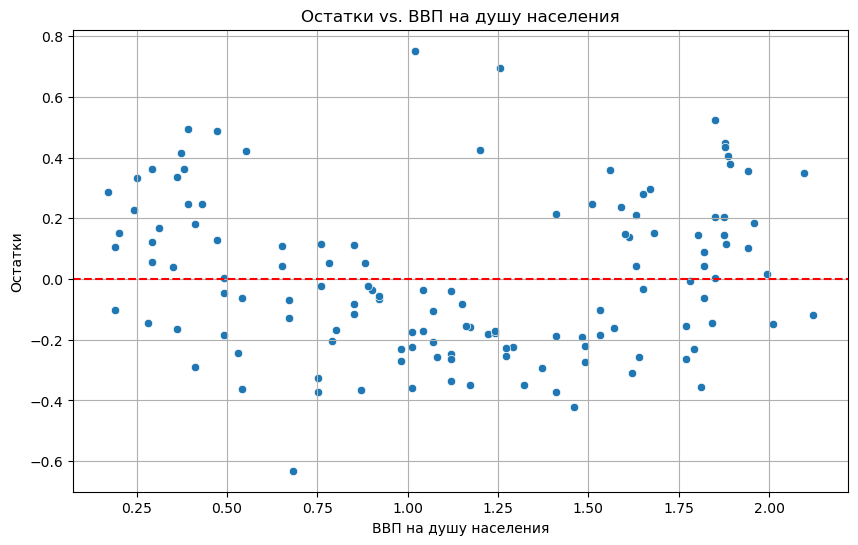

In [94]:
# График остатков относительно 'gdp_per_capita'
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['gdp_per_capita'], y=df['residuals'])
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Остатки vs. ВВП на душу населения')
plt.xlabel('ВВП на душу населения')
plt.ylabel('Остатки')
plt.grid(True)
plt.show()

#### Выводы по графикам остатков:
Если остатки распределены случайным образом вокруг нуля (горизонтальная полоса),
то признаков гетероскедастичности нет. При наличии паттернов (например, "веер",
когда дисперсия остатков увеличивается или уменьшается вдоль оси независимой переменной),
это указывает на гетероскедастичность. На представленных графиках видно, что
разброс остатков кажется примерно постоянным, что говорит об отсутствии явной
гетероскедастичности.

### Тест Бройша — Пагана

In [97]:
# Тест проверяет, зависит ли дисперсия остатков от независимых переменных.
# Нулевая гипотеза: гомоскедастичность (дисперсия остатков постоянна).
# Альтернативная гипотеза: гетероскедастичность (дисперсия остатков не постоянна).
ch2, pval, f_fvalue, f_pval = het_breuschpagan(model.resid, model.model.exog)

print(f"\nТест Бройша — Пагана:")
print(f"  Статистика Хи-квадрат: {ch2:.4f}")
print(f"  P-значение (Хи-квадрат): {pval:.4f}")
print(f"  F-статистика: {f_fvalue:.4f}")
print(f"  P-значение (F-тест): {f_pval:.4f}")



Тест Бройша — Пагана:
  Статистика Хи-квадрат: 8.1054
  P-значение (Хи-квадрат): 0.0174
  F-статистика: 4.2224
  P-значение (F-тест): 0.0168


### Вывод
Оба теста (хи-квадрат и F-тест) указывают на наличие гетероскедастичности в регрессионной модели. Это означает, что дисперсия ошибок не является постоянной и зависит от значений объясняющих переменных. Гетероскедастичность может привести к неэффективности оценок коэффициентов регрессии и искажению стандартных ошибок, что влияет на достоверность гипотетических тестов.

## Cпецификация модели с одной и с двумя независимыми переменными

In [99]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [100]:
# Модель с одной независимой переменной (социальная поддержка)
model_1_var = ols('score ~ social_support', data=df).fit()
r_squared_1 = model_1_var.rsquared
anova_1 = sm.stats.anova_lm(model_1_var, typ=2)

In [101]:
# Модель с двумя независимыми переменными (социальная поддержка и ВВП)
model_2_vars = ols('score ~ social_support + gdp_per_capita', data=df).fit()
r_squared_2 = model_2_vars.rsquared
anova_2 = sm.stats.anova_lm(model_2_vars, typ=2)

In [102]:
print(f"Результаты сравнения моделей:")

print("\n--- Модель с одной переменной (score ~ social_support) ---")
print(f"Коэффициент детерминации (R-squared): {r_squared_1:.4f}")
print("ANOVA:")
print(anova_1)

print("\n--- Модель с двумя переменными (score ~ social_support + gdp_per_capita) ---")
print(f"Коэффициент детерминации (R-squared): {r_squared_2:.4f}")
print("ANOVA:")
print(anova_2)

Результаты сравнения моделей:

--- Модель с одной переменной (score ~ social_support) ---
Коэффициент детерминации (R-squared): 0.9535
ANOVA:
                    sum_sq     df            F        PR(>F)
social_support  193.937557    1.0  2623.782723  3.835308e-87
Residual          9.461152  128.0          NaN           NaN

--- Модель с двумя переменными (score ~ social_support + gdp_per_capita) ---
Коэффициент детерминации (R-squared): 0.9573
ANOVA:
                   sum_sq     df           F        PR(>F)
social_support  37.458925    1.0  547.819880  6.788720e-48
gdp_per_capita   0.777124    1.0   11.365083  9.919495e-04
Residual         8.684028  127.0         NaN           NaN


In [103]:
if r_squared_2 > r_squared_1:
    print("Модель с двумя переменными имеет более высокий коэффициент детерминации (R-squared).")
else:
    print("Модель с одной переменной имеет более высокий коэффициент детерминации (R-squared), что маловероятно при добавлении значимой переменной.")

Модель с двумя переменными имеет более высокий коэффициент детерминации (R-squared).


In [104]:
'''
Сравниваем p-значение для регрессии (sum_sq модели 2 против модели 1)
Нулевая гипотеза ANOVA: все коэффициенты (кроме свободного члена) равны нулю.
Для модели 2, мы фактически тестируем, добавляет ли 'gdp_per_capita' значимый вклад
к модели, объясняемой только 'social_support'.
Если p-значение для 'gdp_per_capita' в ANOVA модели 2 мало (например, < 0.05),
то эта переменная значимо улучшает модель.
'''
p_value_gdp = anova_2['PR(>F)'][1] # p-значение для gdp_per_capita

if p_value_gdp < 0.05:
    print(f"ANOVA-тест для модели с двумя переменными показал, что 'gdp_per_capita' является статистически значимым предиктором (p-value = {p_value_gdp:.4f}).")
    print("Это означает, что добавление 'gdp_per_capita' к модели значительно улучшает ее объясняющую способность.")
    print("\nПредпочтительная модель: модель с двумя независимыми переменными, так как она объясняет больше вариации зависимой переменной и имеет статистически значимые предикторы.")
else:
    print(f"ANOVA-тест для модели с двумя переменными показал, что 'gdp_per_capita' не является статистически значимым предиктором (p-value = {p_value_gdp:.4f}).")
    print("В этом случае, несмотря на более высокий R-squared, добавление переменной не оправдано с точки зрения статистической значимости.")
    print("\nРекомендуется использовать модель с одной переменной, если прирост R-squared невелик, или модель с двумя переменными, если прирост R-squared существенен и интерпретация обоих предикторов важна.")

ANOVA-тест для модели с двумя переменными показал, что 'gdp_per_capita' является статистически значимым предиктором (p-value = 0.0010).
Это означает, что добавление 'gdp_per_capita' к модели значительно улучшает ее объясняющую способность.

Предпочтительная модель: модель с двумя независимыми переменными, так как она объясняет больше вариации зависимой переменной и имеет статистически значимые предикторы.


C:\Users\indiv\AppData\Local\Temp\ipykernel_17480\2997892852.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value_gdp = anova_2['PR(>F)'][1] # p-значение для gdp_per_capita
